In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math as m



#*WHAT LOOK WRONG :*
- First thing ,the data which I have taken that contains more such as wrong records like given 3 column but the data or record contains 4 values that is not to be possible for loading data .When try to load it then it cannot be loaded at first ,then i use "on_bad_lines" method here. This manner I skip those misleading records.

- Here we can see many null values in different differet columns.

- I can also notice here that the data types of "budget","id" are object type.

- Here count of 'id' column and unique of 'id' are not both same.

In [31]:
import pandas as pd
import requests
import zipfile
import io

url = "https://github.com/premlatamd/MCA-PROJECT-EDA/raw/refs/heads/main/movies_metadata.csv.zip"

response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open("movies_metadata.csv") as f:
        df = pd.read_csv(f, low_memory=False)

print("Shape:", df.shape)
print(df.head())
print(df.info())
print(df.shape)

print(df.shape)
print(df.shape)

print(df.head())

print(df.info())

print(df.columns)

print(df.columns.tolist())

print(df.describe)





Shape: (45466, 24)
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4                     [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_language  \
0  http://toystory.disney.com/toy-story    862  tt0114709                en   
1                                   NaN   8844 

In [32]:
print("Nmber of null values are :")
print(df.isna().sum().sort_values(ascending=False))
print("\n")

print("Duplicate values are:")
print(df.duplicated().sum())


print("\nBudget and id are in object:")
print(df.info())

print("\nMean and Median and max comparision : ")
print(df.describe(include='all'))

print("\n duplicate in id column :")
print(df['id'].duplicated().sum())

print("\ncolumn adult contains abnormal value which may be movie description and also True  only 9 times")
print(df['adult'].value_counts(dropna=False))


print("\nNumber of zeroes in revenue : ",(df['revenue']==0).sum())
print("\nNumber of zeroes in runtime : ",(df['runtime']==0).sum())

Nmber of null values are :
belongs_to_collection    40972
homepage                 37684
tagline                  25054
overview                   954
poster_path                386
runtime                    263
status                      87
release_date                87
imdb_id                     17
original_language           11
vote_average                 6
vote_count                   6
title                        6
video                        6
spoken_languages             6
revenue                      6
popularity                   5
production_countries         3
production_companies         3
genres                       0
id                           0
adult                        0
budget                       0
original_title               0
dtype: int64


Duplicate values are:
17

Budget and id are in object:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype 

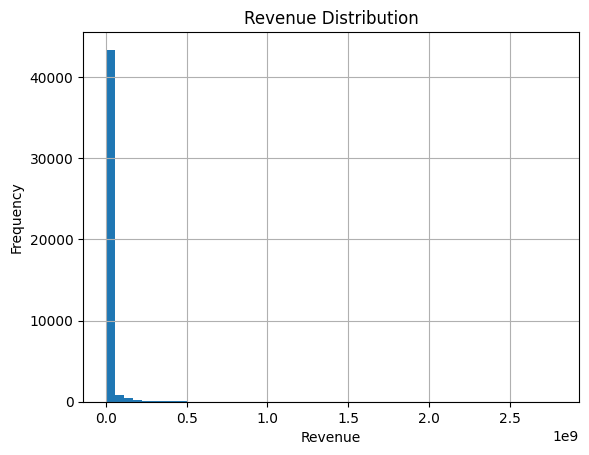

Mean   : 11209348.539265288
Median : 0.0
Std    : 64332246.740631126
Min    : 0.0
Max    : 2787965087.0


In [33]:
#as my revenue column type is object ,so at first make it as numerical
#for finding mean etc.
"""
The revenue distribution is highly right-skewed, with most movies concentrated
near zero revenue. A small number of movies have extremely high revenues,
creating a long right tail. The large gap between the mean (19240042.430968307)
and median (0) suggests the presence of many zero values and significant
outliers.
"""
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['revenue'].hist(bins=50)
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.title("Revenue Distribution")
plt.show()


print("Mean   :", df['revenue'].mean())
print("Median :", df['revenue'].median())
print("Std    :", df['revenue'].std())
print("Min    :", df['revenue'].min())
print("Max    :", df['revenue'].max())



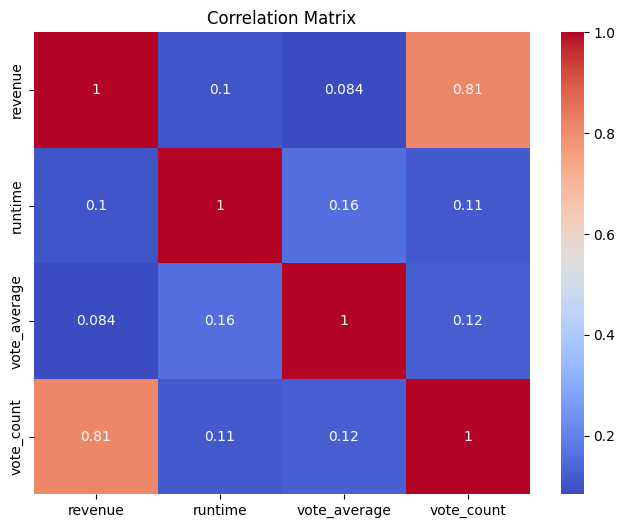

In [ ]:
#1. Correlation Matrix + Heatmap
"""
A correlation matrix was generated for the numerical features: Revenue, Runtime,
Vote Average, and Vote Count. The heatmap helps visualize the strength of linear
relationships between these variables.Thats mean which attibute are strong or
which attribute are weak related to the target.The strongest positive correlation was
observed between Revenue and Vote Count (0.80), indicating that movies receiving
more revenue as the vote of the people gradually increased.In contrast,
Runtime (0.13) and Vote Average (0.085) showed weak correlations with Revenue,
says that these features have only a limited linear relationship with the
target variable.
"""

num_cols = ['revenue','runtime','vote_average','vote_count']
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

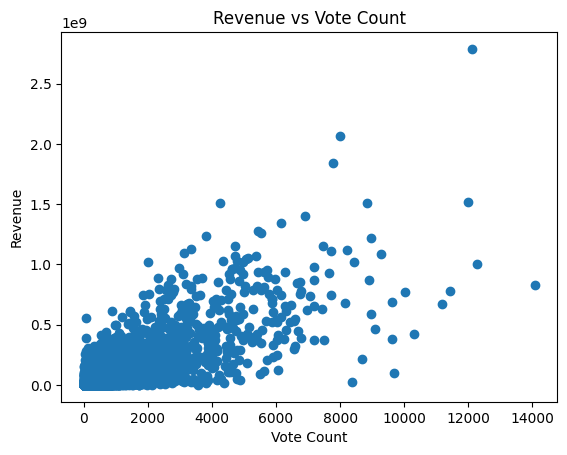

In [34]:
#Revenue vs Vote count
"""
The scatter plot between Vote Count and Revenue shows a noticeable positive trend.
Movies with higher vote counts generally generate higher revenue.This
observation is consistent with the correlation value of 0.80, making Vote Count
one of the most influential features in the dataset.However Some outliers are
also noticeable.
"""
plt.scatter(df['vote_count'], df['revenue'])
plt.xlabel("Vote Count")
plt.ylabel("Revenue")
plt.title("Revenue vs Vote Count")
plt.show()
#Revenue vs Vote Count

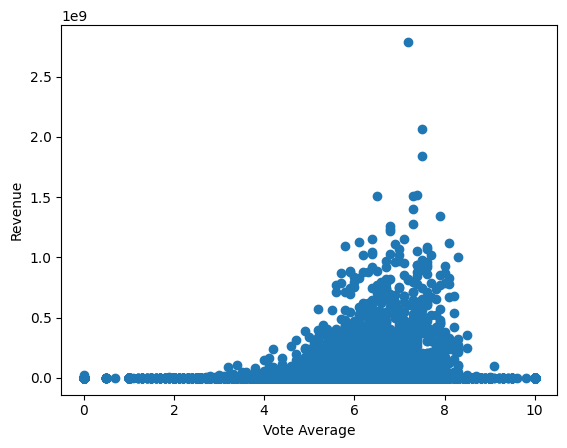

In [36]:
#Revenue vs Vote Average
"""
The relationship between Vote Average and Revenue appears weak according to the
heatmap.Several movies with moderate ratings generate very high revenue, while
some highly rated movies generate relatively low revenue.This indicates that
audience ratings alone cannot fully explain a movie's financial success.
"""
plt.scatter(df['vote_average'], df['revenue'])
plt.xlabel("Vote Average")
plt.ylabel("Revenue")
plt.show()

/tmp/ipykernel_3060/905565082.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


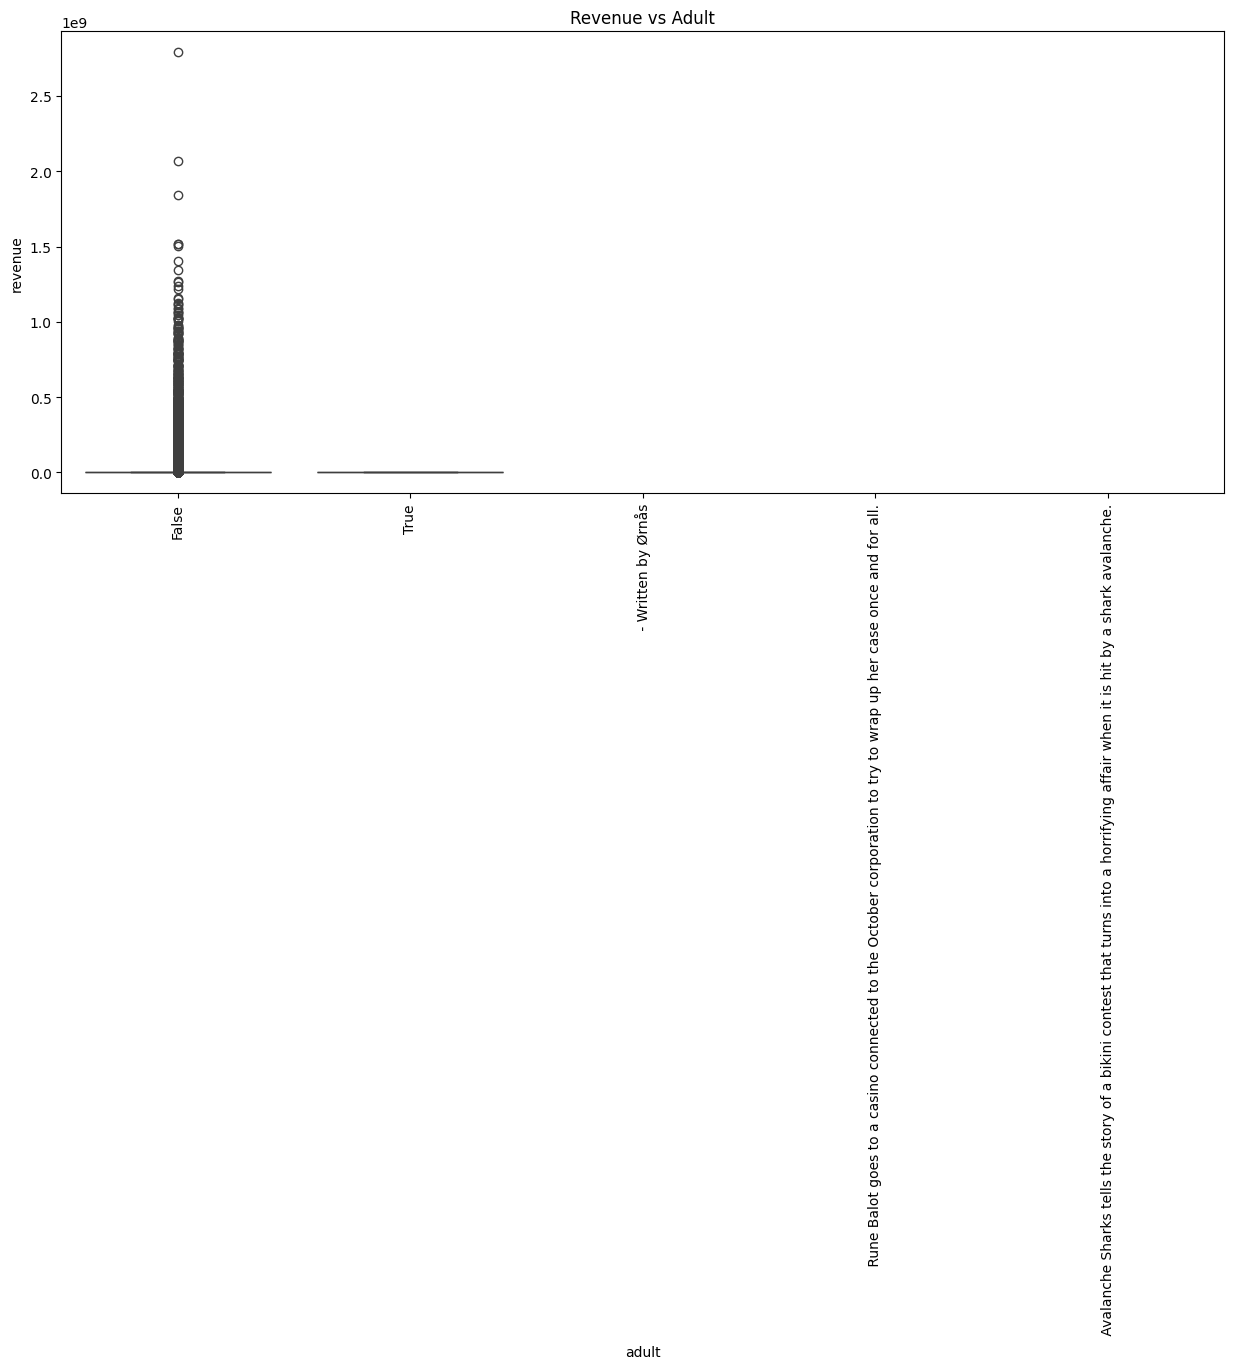

In [35]:
#Categorical Feature → Boxplot
#Revenue vs Adult
"""
here we can easily observe that in adult column 3 values are unwanted or contain
Sentinel values like it pretending to be data but it is not really a data.
"""

plt.figure(figsize=(15,6))

sns.boxplot(x='adult',y='revenue',data=df)
plt.xticks(rotation=90)
plt.title("Revenue vs Adult")
plt.tight_layout()
plt.show()

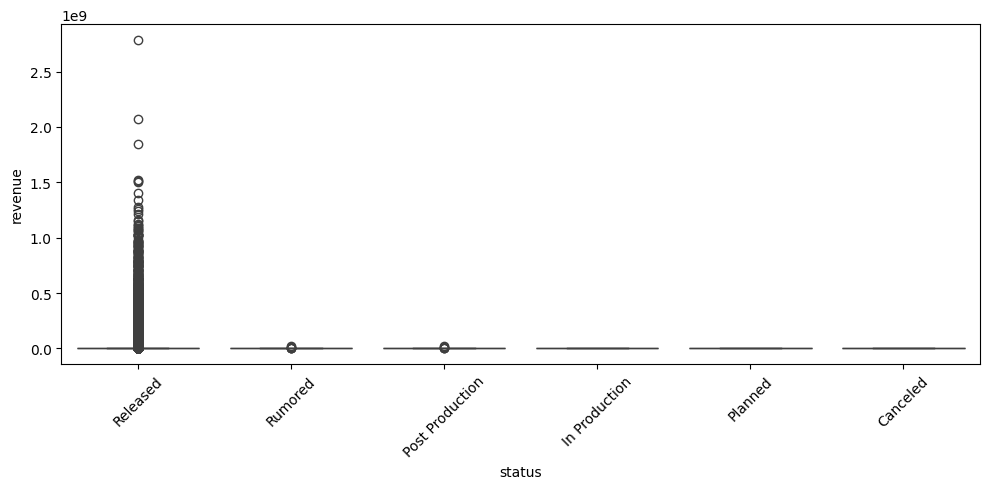

In [37]:
#Revenue vs status
plt.figure(figsize=(10,5))
sns.boxplot(x='status', y='revenue', data=df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

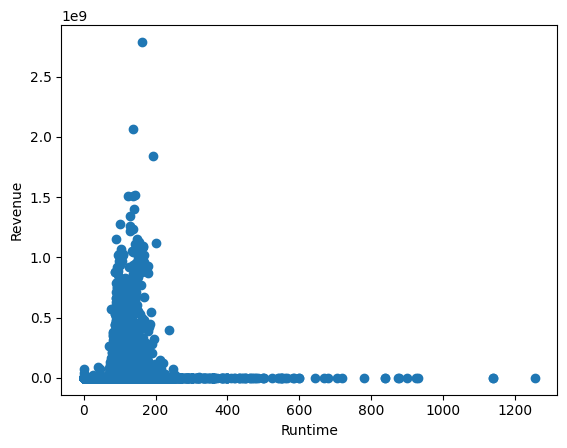

In [38]:
#Revenue vs runtime
plt.scatter(df['runtime'], df['revenue'])
plt.xlabel("Runtime")
plt.ylabel("Revenue")
plt.show()

## *Example of Misleading Correlation*

Runtime provides an example where correlation can be misleading.

The correlation between Runtime and Revenue is only 0.13, which suggests a very weak linear relationship. However, the scatter plot shows that most blockbuster movies are concentrated within a runtime range of approximately 80 - 200 minutes,indicating a pattern which is not linear.This shows that correlation alone may not capture all patterns present in the data.


---

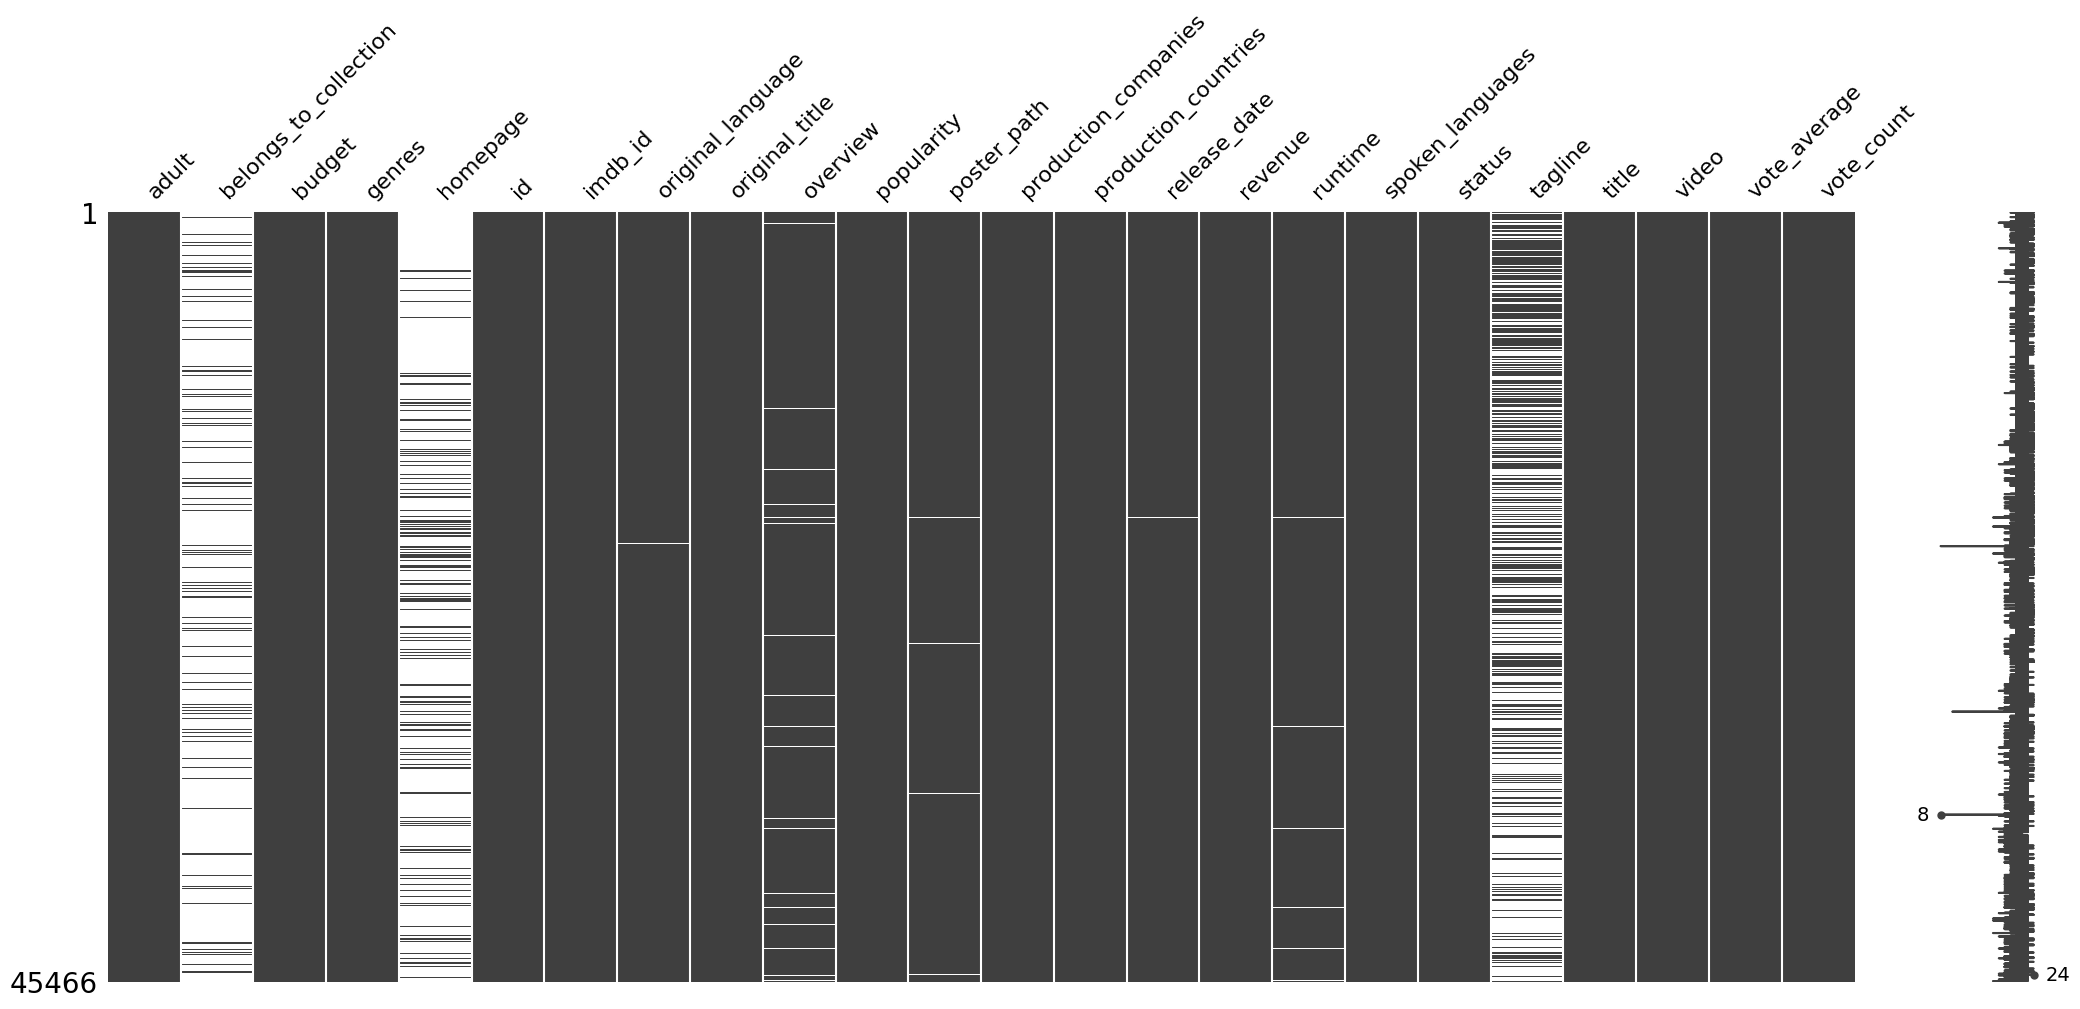

In [39]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)
plt.show()

In [40]:
df['belongs_missing'] = df['belongs_to_collection'].isnull().astype(int)
df.groupby('belongs_missing')['revenue'].mean()

,revenue
belongs_missing,
0,5.460957e+07
1,6.453015e+06


In [41]:
df['revenue_per_vote'] = df['revenue'] / (df['vote_count'] + 1)

In [42]:
"""
Pearson correlation between Runtime and Revenue was 0.104, indicating a very
weak linear relationship.Spearman correlation was 0.254, which is higher than
Pearson. This suggests that there is a weak monotonic trend between Runtime and
Revenue, but the relationship is not strictly linear.

The difference between Pearson and Spearman indicates that revenue does not
increase in a straight-line manner with runtime.
"""
from scipy.stats import pearsonr, spearmanr
temp = df[['runtime','revenue']].dropna()

pearson_corr, _ = pearsonr(temp['runtime'], temp['revenue'])
spearman_corr, _ = spearmanr(temp['runtime'], temp['revenue'])

print("Pearson:", pearson_corr)
print("Spearman:", spearman_corr)

Pearson: 0.10391677021239065
Spearman: 0.2542990550278441
